# Deterministic Classification of Metal-Oxide Nanoparticle Cytotoxicity

This notebook implements the preprocessing, group-aware train/test split, class balancing, and evaluation of three deterministic classifiers (Random Forest, linear SVM, and Multilayer Perceptron) for predicting the cytotoxicity of metal-oxide nanoparticles from physicochemical descriptors.

The evaluation protocol accounts for the presence of technical replicates in the dataset: samples sharing the same physicochemical descriptor vector (repeated experimental conditions) are always assigned entirely to either the training set or the test set, and the Synthetic Minority Oversampling Technique (SMOTE) is applied only after the split, to the training partition alone. This prevents duplicate-row leakage and synthetic-neighbor leakage between the two partitions.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score,
                              roc_curve, auc, precision_recall_curve, average_precision_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
colors = ["#2c3e50", "#8c3a3a", "#4a7c7c", "#5b7c99", "#7f8c8d", "#a0522d", "#6b7a8f", "#3d5a6c"]
model_colors = {'Random Forest': colors[0], 'SVM (linear)': colors[1], 'MLP': colors[2]}
RANDOM_SEED = 42


## 1. Data loading

In [2]:
DATA_PATH = "dataset_nanotox_datos_originales.xlsx"
df_nuevo = pd.read_excel(DATA_PATH)
print(df_nuevo.shape)
df_nuevo[['NPs','hydrosize','surfcharge','surfarea','Ec','Expotime','dosage','e','NOxygen','class']].head()


(483, 24)


,NPs,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen,class
0,Al2O3,267.0,36.3,64.7,-1.51,24,0.001,1.61,3,nonToxic
1,Al2O3,267.0,36.3,64.7,-1.51,24,0.010,1.61,3,nonToxic
2,Al2O3,267.0,36.3,64.7,-1.51,24,0.100,1.61,3,nonToxic
3,Al2O3,267.0,36.3,64.7,-1.51,24,1.000,1.61,3,nonToxic
4,Al2O3,267.0,36.3,64.7,-1.51,24,5.000,1.61,3,nonToxic


## 2. Descriptor transformations

Domain-specific transformations are applied to each descriptor prior to scaling: logarithmic transforms for size- and electronegativity-related variables, z-score standardization for surface charge, an offset logarithm for conduction band energy, base-10 logarithm for dosage, and a log2 transform for exposure time normalized to a 3-hour baseline.

In [3]:
def normalise(df):
    df = df.copy()
    if 'hydrosize' in df.columns: df['hydrosize'] = np.log(df['hydrosize'])
    if 'surfarea' in df.columns: df['surfarea'] = np.log(df['surfarea'])
    if 'surfcharge' in df.columns: df['surfcharge'] = StandardScaler().fit_transform(df[['surfcharge']])
    if 'Ec' in df.columns: df['Ec'] = np.log(6.17 + df['Ec'])
    if 'dosage' in df.columns: df['dosage'] = np.log10(df['dosage'])
    if 'Expotime' in df.columns: df['Expotime'] = np.log(df['Expotime'] / 3) / np.log(2)
    if 'e' in df.columns: df['e'] = np.log(df['e'])
    return df

features = ['hydrosize','surfcharge','surfarea','Ec','Expotime','dosage','e','NOxygen']
features = [f for f in features if f in df_nuevo.columns]

df_nuevo_norm = normalise(df_nuevo)
df_nuevo_norm['class_bin'] = df_nuevo_norm['class'].map({'nonToxic': 0, 'Toxic': 1})
df_nuevo_norm[features + ['class_bin']].head()


,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,e,NOxygen,class_bin
0,5.587249,1.656714,4.169761,1.539015,3.0,-3.00000,0.476234,3,0
1,5.587249,1.656714,4.169761,1.539015,3.0,-2.00000,0.476234,3,0
2,5.587249,1.656714,4.169761,1.539015,3.0,-1.00000,0.476234,3,0
3,5.587249,1.656714,4.169761,1.539015,3.0,0.00000,0.476234,3,0
4,5.587249,1.656714,4.169761,1.539015,3.0,0.69897,0.476234,3,0


## 3. Group-aware train/test split and class balancing

The grouping key is the full descriptor vector (the unique experimental condition), computed from the untransformed values to avoid floating-point precision issues introduced by the logarithmic transforms. Rows are grouped, each group is assigned its majority class, and complete groups (never individual rows) are split 80/20, stratified on the group-level class. SMOTE is then applied only to the training partition.

In [4]:
df_nuevo['_group_key'] = df_nuevo[features].astype(str).agg('|'.join, axis=1)
n_groups = df_nuevo['_group_key'].nunique()
print(f"Rows: {len(df_nuevo)}  Unique experimental conditions: {n_groups}")
print(f"Rows sharing at least one technical replicate: {df_nuevo.duplicated(subset=features, keep=False).sum()}")

df_nuevo_norm['_group_key'] = df_nuevo['_group_key'].values

group_majority = df_nuevo_norm.groupby('_group_key')['class_bin'].agg(lambda s: s.mode().iloc[0])
groups = group_majority.index.values
group_labels = group_majority.values

train_groups, test_groups = train_test_split(
    groups, test_size=0.20, random_state=RANDOM_SEED, stratify=group_labels
)
train_groups, test_groups = set(train_groups), set(test_groups)

train_mask = df_nuevo_norm['_group_key'].isin(train_groups)
test_mask = df_nuevo_norm['_group_key'].isin(test_groups)
assert (train_mask | test_mask).all() and not (train_mask & test_mask).any(), "A group was split across train and test"

X_train_raw = df_nuevo_norm.loc[train_mask, features]
y_train_raw = df_nuevo_norm.loc[train_mask, 'class_bin']
X_test = df_nuevo_norm.loc[test_mask, features]
y_test = df_nuevo_norm.loc[test_mask, 'class_bin']

print(f"\nTrain: {len(X_train_raw)} rows (non-toxic={ (y_train_raw==0).sum() }, toxic={ (y_train_raw==1).sum() })")
print(f"Test:  {len(X_test)} rows (non-toxic={ (y_test==0).sum() }, toxic={ (y_test==1).sum() }); original class prevalence is preserved, untouched by SMOTE")


Rows: 483  Unique experimental conditions: 353
Rows sharing at least one technical replicate: 240

Train: 396 rows (non-toxic=332, toxic=64)
Test:  87 rows (non-toxic=73, toxic=14); original class prevalence is preserved, untouched by SMOTE


In [5]:
smote = SMOTE(random_state=RANDOM_SEED)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)
print(f"Training set after SMOTE: non-toxic={ (y_train==0).sum() }, toxic={ (y_train==1).sum() }")


Training set after SMOTE: non-toxic=332, toxic=332


## 4. Class distribution before and after SMOTE (training partition only)

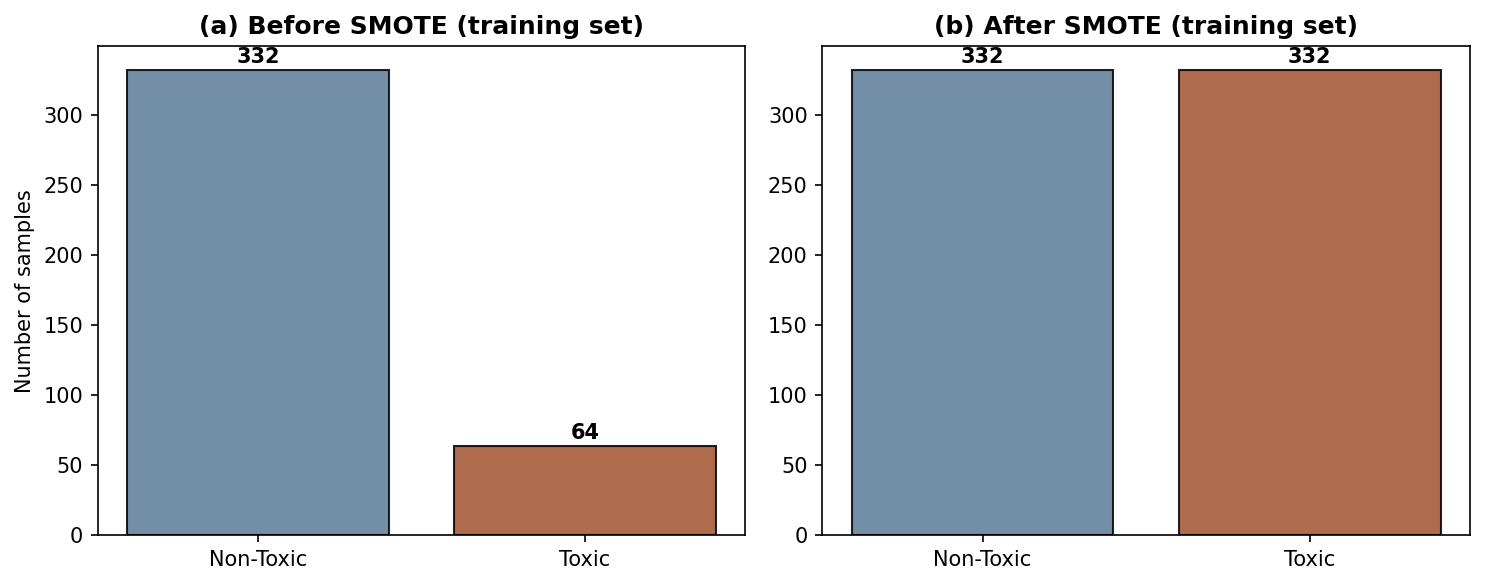

Class imbalance ratio in the training set: 5.19:1
Toxic prevalence in the test set: 16.1%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = y_train_raw.value_counts().sort_index()
axes[0].bar(['Non-Toxic', 'Toxic'], before.values, color=[colors[3], colors[5]], edgecolor='black', alpha=0.85)
axes[0].set_title('(a) Before SMOTE (training set)', fontweight='bold')
axes[0].set_ylabel('Number of samples')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

after = y_train.value_counts().sort_index()
axes[1].bar(['Non-Toxic', 'Toxic'], after.values, color=[colors[3], colors[5]], edgecolor='black', alpha=0.85)
axes[1].set_title('(b) After SMOTE (training set)', fontweight='bold')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_6_smote_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

ratio = before.max() / before.min()
print(f"Class imbalance ratio in the training set: {ratio:.2f}:1")
print(f"Toxic prevalence in the test set: {(y_test==1).mean()*100:.1f}%")


## 5. Model training

In [7]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'SVM (linear)': SVC(kernel='linear', probability=True, random_state=RANDOM_SEED, class_weight='balanced'),
    'MLP': MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=RANDOM_SEED),
}

y_preds, y_probs = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_preds[name] = model.predict(X_test)
    y_probs[name] = model.predict_proba(X_test)[:, 1]

print("Models trained on the post-SMOTE training set and evaluated on the held-out test set.")


Models trained on the post-SMOTE training set and evaluated on the held-out test set.


## 6. Confusion matrices

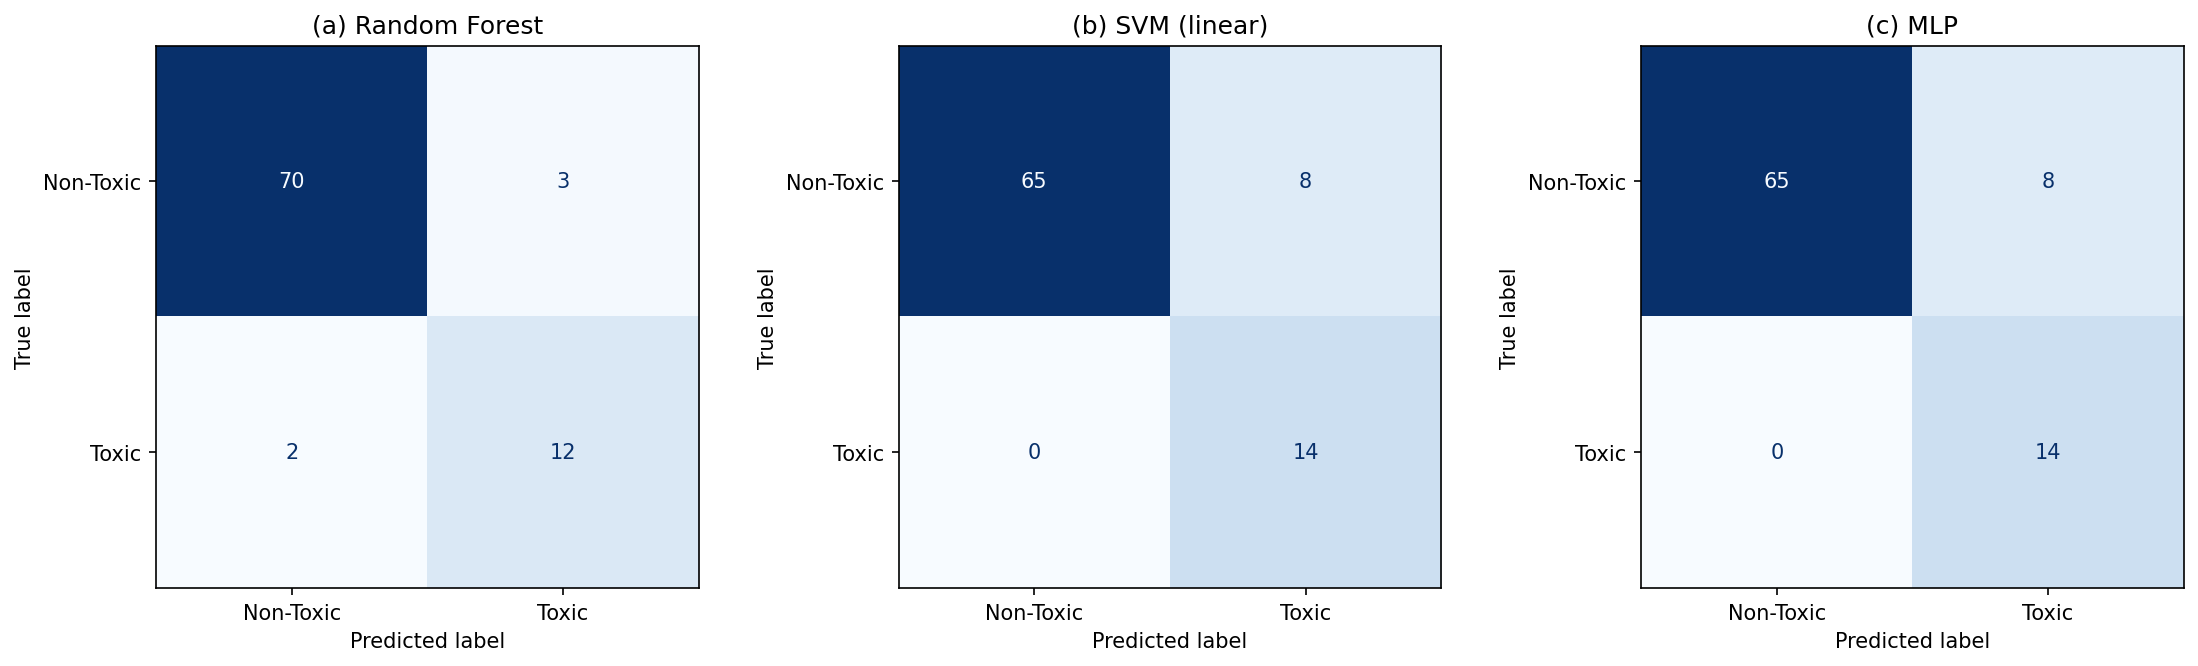

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for idx, name in enumerate(models):
    cm = confusion_matrix(y_test, y_preds[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Toxic', 'Toxic'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'({chr(97+idx)}) {name}')
plt.tight_layout()
plt.savefig('fig5_4_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Performance metrics

In [9]:
rows = []
for name in models:
    y_pred, y_prob = y_preds[name], y_probs[name]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    fnr = fn / (fn + tp)
    fpr_curve, tpr_curve, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)
    pr_auc = average_precision_score(y_test, y_prob)
    rows.append([name, acc, rec, prec, f1, fnr, roc_auc, pr_auc])

table51 = pd.DataFrame(rows, columns=['Model','Accuracy','Recall','Precision','F1','FNR','ROC-AUC','PR-AUC'])
table51 = table51.set_index('Model').round(3)
table51.to_csv('Table5_1.csv')
table51


,Accuracy,Recall,Precision,F1,FNR,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.943,0.857,0.800,0.828,0.143,0.977,0.898
SVM (linear),0.908,1.000,0.636,0.778,0.000,0.957,0.717
MLP,0.908,1.000,0.636,0.778,0.000,0.955,0.669


## 8. ROC and precision-recall curves

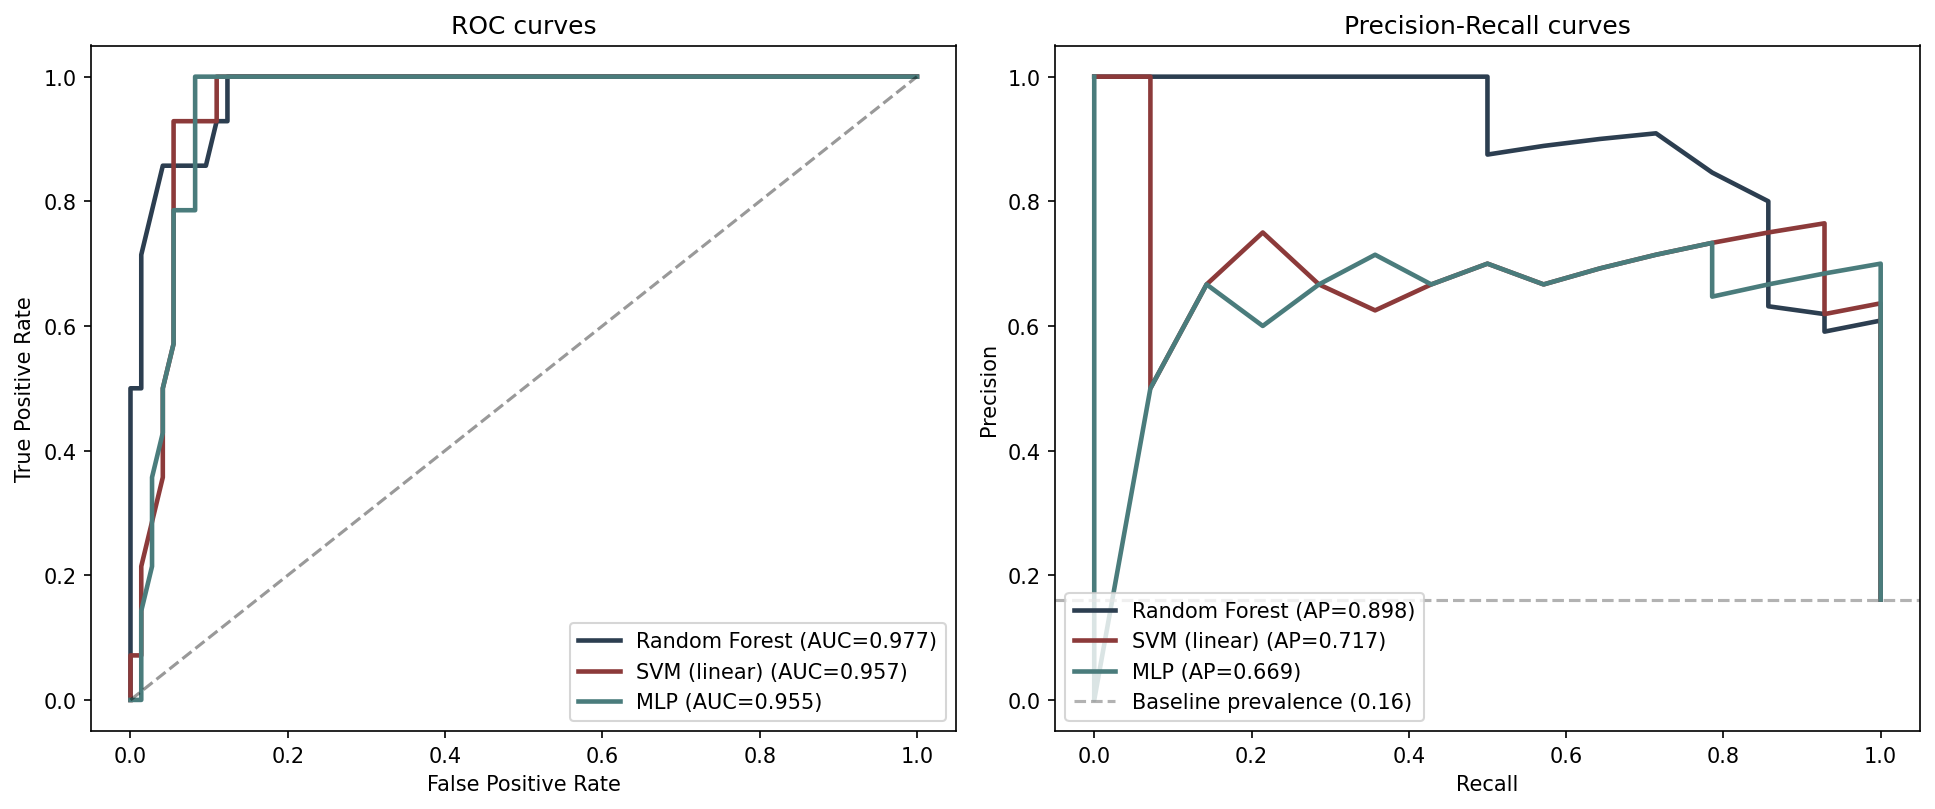

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name in models:
    fpr_c, tpr_c, _ = roc_curve(y_test, y_probs[name])
    roc_auc = auc(fpr_c, tpr_c)
    axes[0].plot(fpr_c, tpr_c, linewidth=2.2, color=model_colors[name], label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves'); axes[0].legend(loc='lower right')

baseline = (y_test==1).mean()
for name in models:
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_probs[name])
    ap = average_precision_score(y_test, y_probs[name])
    axes[1].plot(rec_c, prec_c, linewidth=2.2, color=model_colors[name], label=f'{name} (AP={ap:.3f})')
axes[1].axhline(baseline, color='gray', linestyle='--', alpha=0.6, label=f'Baseline prevalence ({baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves'); axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('fig5_5_roc_curves.png', dpi=300, bbox_inches='tight')
plt.savefig('fig5_6_precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Feature importance (Random Forest)

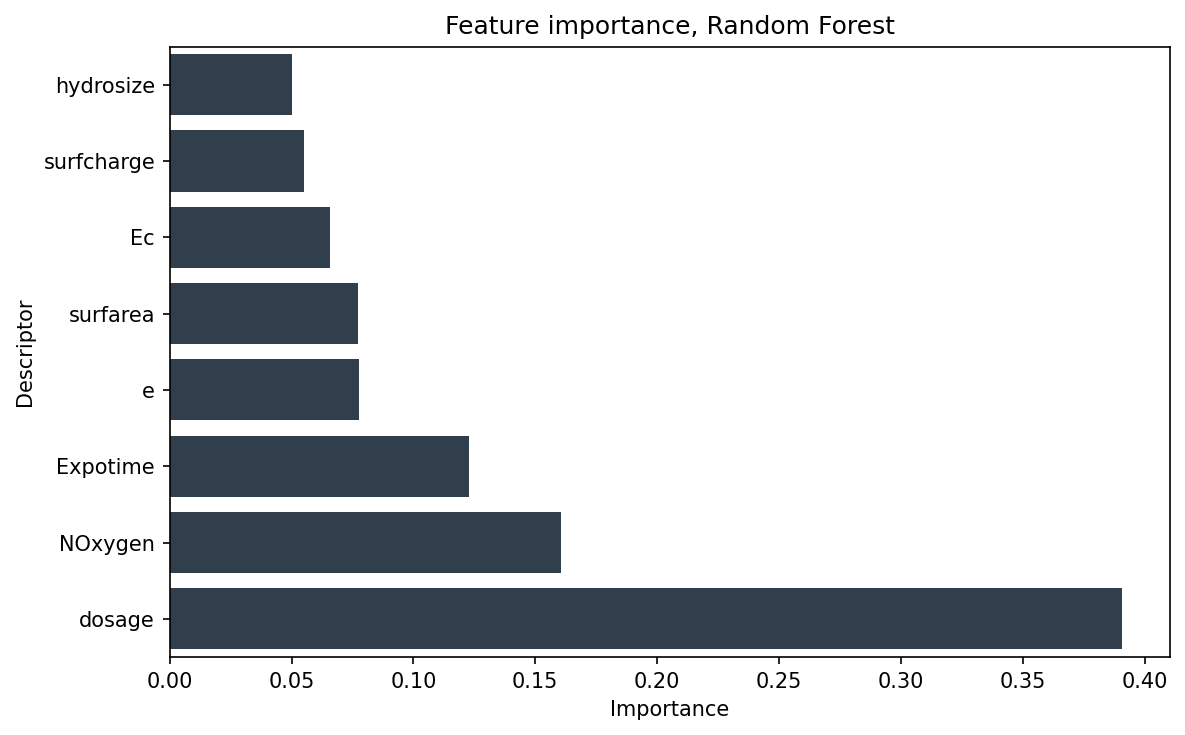

In [11]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
plt.figure(figsize=(8,5))
order = np.argsort(importances)
sns.barplot(x=importances[order], y=np.array(features)[order], color=colors[0])
plt.title('Feature importance, Random Forest')
plt.xlabel('Importance'); plt.ylabel('Descriptor')
plt.tight_layout()
plt.savefig('fig5_9_feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Correlation and multicollinearity analysis

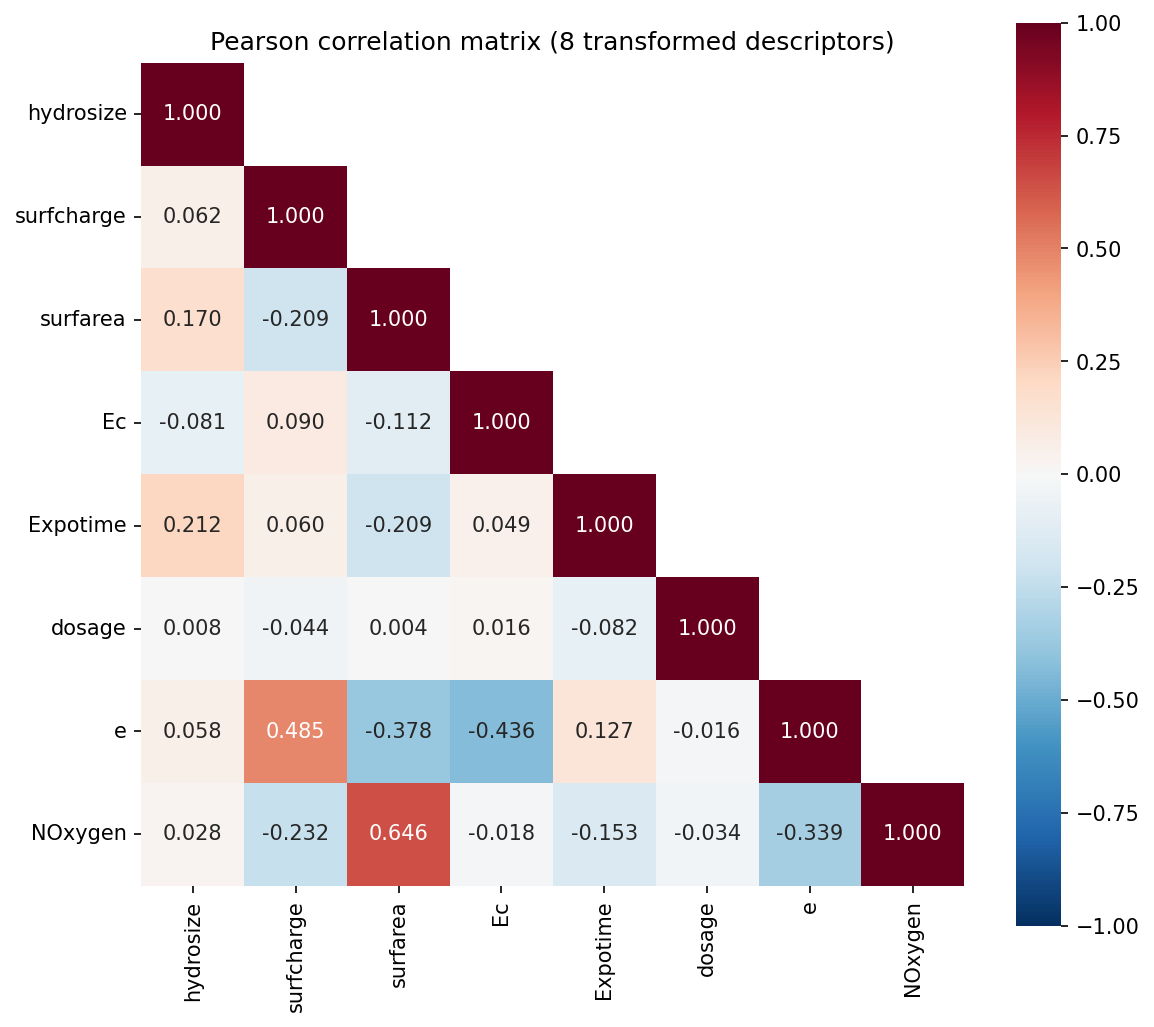

,Variable,VIF
6,e,2.390420
2,surfarea,2.135117
7,NOxygen,1.781147
3,Ec,1.660784
1,surfcharge,1.574094
4,Expotime,1.136491
0,hydrosize,1.133134
5,dosage,1.014312


In [12]:
corr_matrix = df_nuevo_norm[features].corr()
plt.figure(figsize=(8,7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Pearson correlation matrix (8 transformed descriptors)')
plt.tight_layout()
plt.savefig('fig4_4_pearson_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

X_vif = df_nuevo_norm[features].dropna()
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif_data


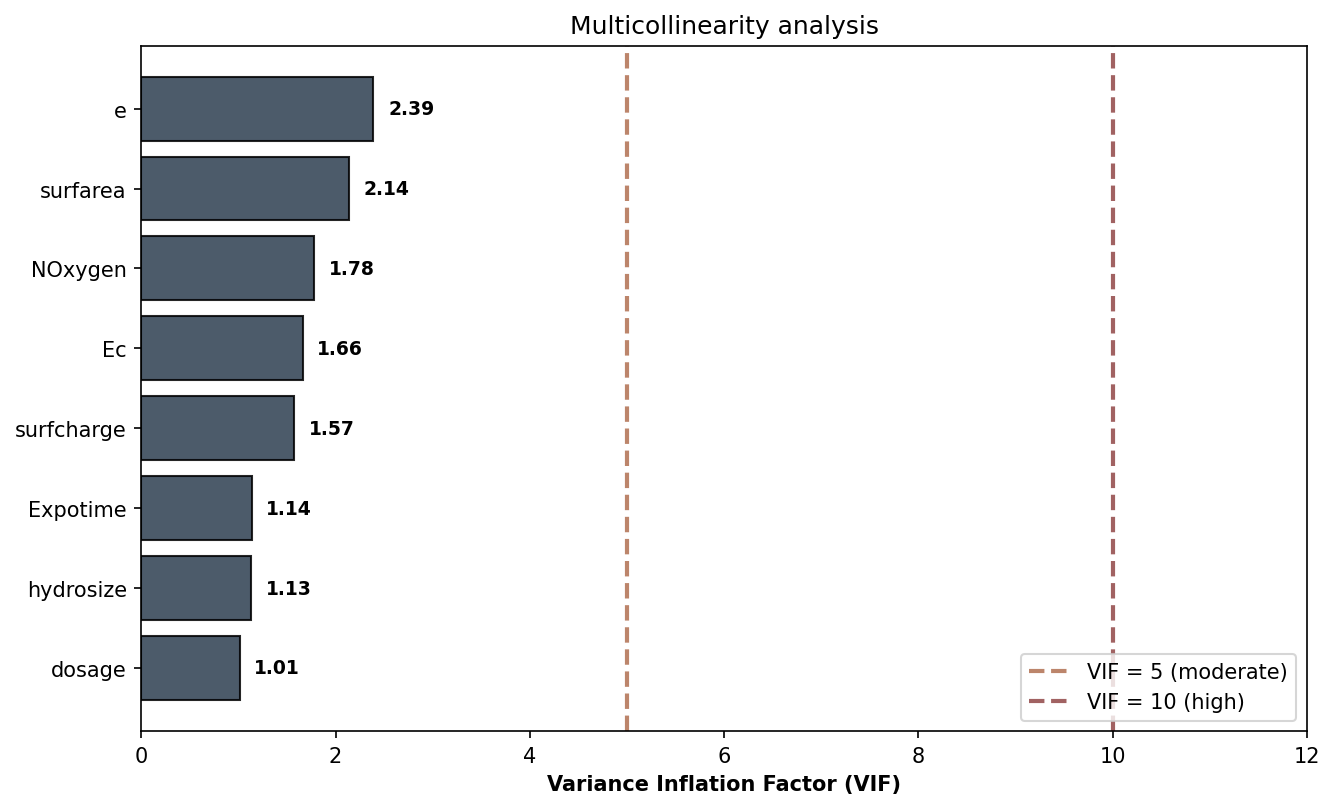

In [13]:
colors_vif = ["#2c3e50", "#8c3a3a", "#4a7c7c", "#5b7c99", "#7f8c8d", "#a0522d", "#6b7a8f", "#3d5a6c"]
vif_sorted = vif_data.sort_values('VIF')
fig, ax = plt.subplots(figsize=(9,5.5))
bar_colors = [colors_vif[5] if v>10 else colors_vif[3] if v>5 else colors_vif[0] for v in vif_sorted['VIF']]
ax.barh(vif_sorted['Variable'], vif_sorted['VIF'], color=bar_colors, edgecolor='black', alpha=0.85)
ax.axvline(5, color='#a0522d', linestyle='--', linewidth=2, alpha=0.7, label='VIF = 5 (moderate)')
ax.axvline(10, color='#7a2020', linestyle='--', linewidth=2, alpha=0.7, label='VIF = 10 (high)')
for i,(var,v) in enumerate(zip(vif_sorted['Variable'], vif_sorted['VIF'])):
    ax.text(v+0.15, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Variance Inflation Factor (VIF)', fontweight='bold')
ax.set_title('Multicollinearity analysis')
ax.set_xlim(0, 12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig4_5_vif_analysis.jpeg', dpi=300, bbox_inches='tight')
plt.show()


## 11. Learning curves

SMOTE is applied inside each cross-validation fold via an imbalanced-learn pipeline, using only the pre-SMOTE training partition, so that no synthetic sample crosses between the training and validation folds of the cross-validation procedure.

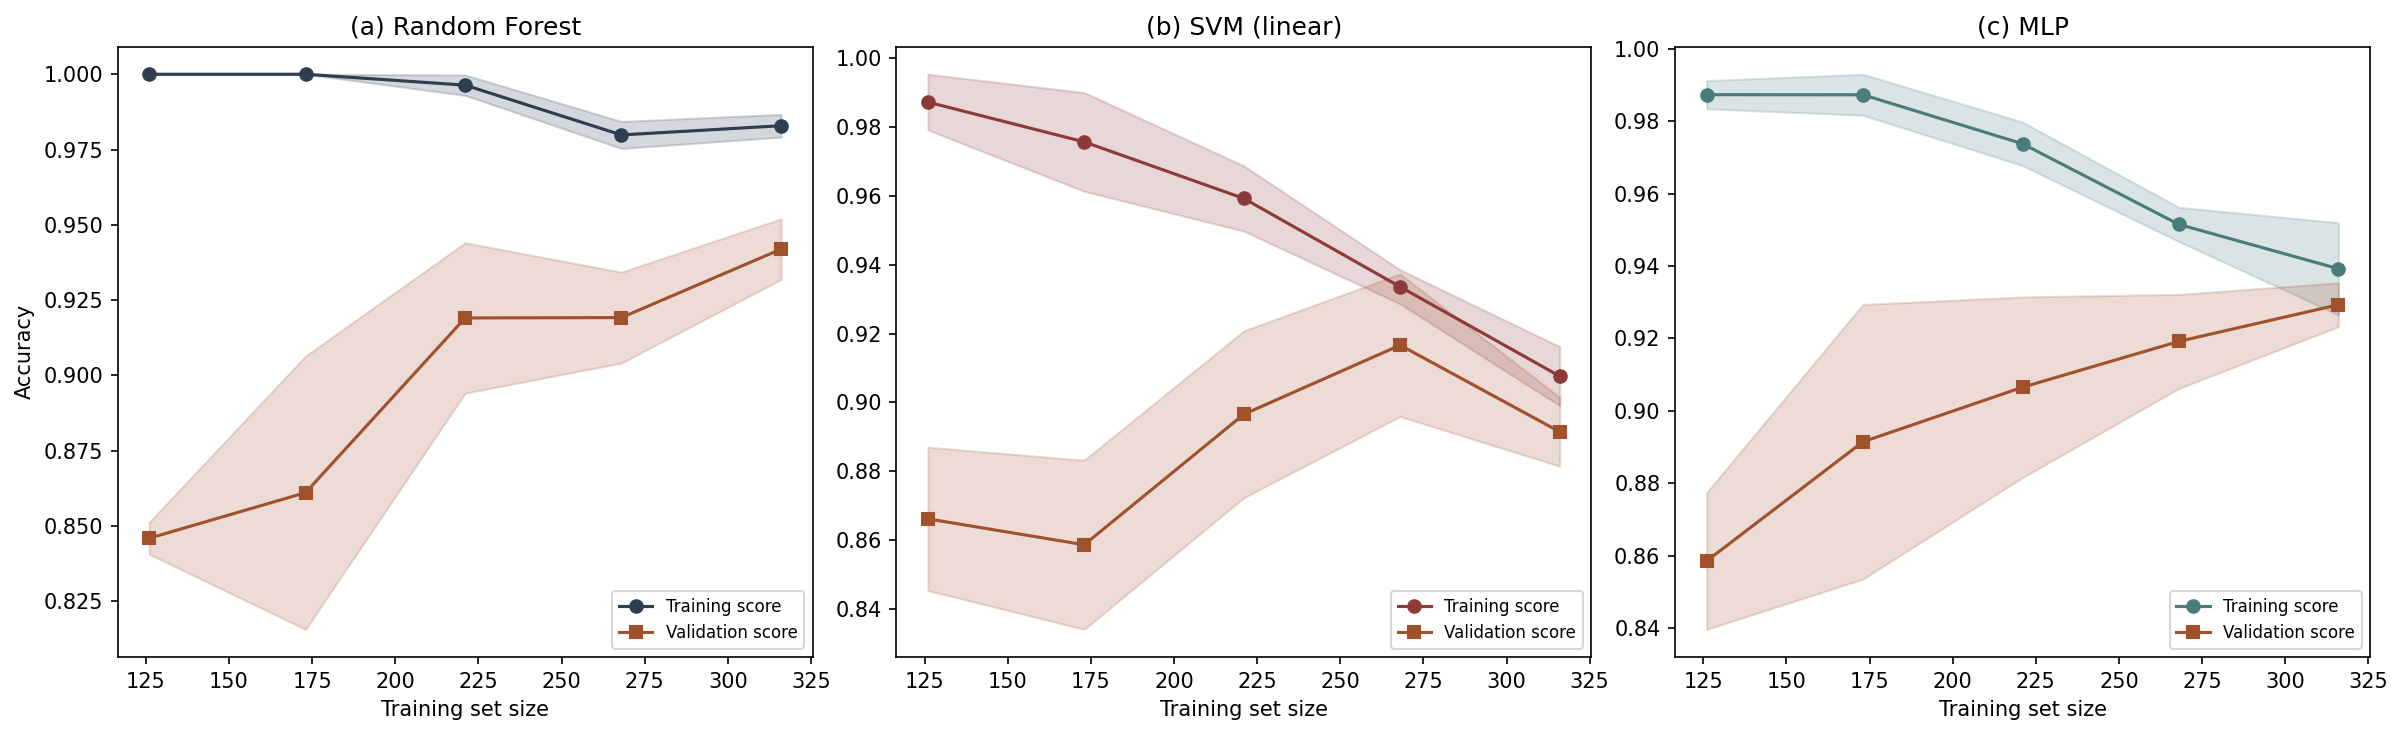

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, base_model) in enumerate(models.items()):
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=1)),
        ('clf', base_model)
    ])
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train_raw, y_train_raw,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        train_sizes=np.linspace(0.4, 1.0, 5),
        scoring='accuracy', n_jobs=-1
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    axes[idx].plot(train_sizes, train_mean, 'o-', color=model_colors[name], label='Training score')
    axes[idx].fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2, color=model_colors[name])
    axes[idx].plot(train_sizes, val_mean, 's-', color=colors[5], label='Validation score')
    axes[idx].fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2, color=colors[5])
    axes[idx].set_title(f'({chr(97+idx)}) {name}')
    axes[idx].set_xlabel('Training set size')
    if idx == 0: axes[idx].set_ylabel('Accuracy')
    axes[idx].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('fig5_8_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Summary

In [15]:
print("=== Table 5.1: deterministic classifier performance ===")
print(table51)
print(f"\nTest set size: {len(X_test)}  (non-toxic={(y_test==0).sum()}, toxic={(y_test==1).sum()})")


=== Table 5.1: deterministic classifier performance ===
               Accuracy  Recall  Precision     F1    FNR  ROC-AUC  PR-AUC
Model                                                                    
Random Forest     0.943   0.857      0.800  0.828  0.143    0.977   0.898
SVM (linear)      0.908   1.000      0.636  0.778  0.000    0.957   0.717
MLP               0.908   1.000      0.636  0.778  0.000    0.955   0.669

Test set size: 87  (non-toxic=73, toxic=14)


## 13. Robustness check: grouping by experimental design

As an alternative to grouping strictly by the descriptor vector, this section groups samples by nanoparticle type, cell line, cell type, exposure time, and dosage, a stricter definition of a replicate that also captures cases where the same nominal condition was reported with slightly different measured physicochemical values across the literature sources compiled in the dataset. The full split, training, and evaluation pipeline is repeated under this alternative grouping to confirm that the results in Table 5.1 do not depend on the specific choice of grouping key.

In [16]:
design_keys = ['NPs','Cellline','Celltype','Expotime','dosage']
df_nuevo['_design_key'] = df_nuevo[design_keys].astype(str).agg('|'.join, axis=1)
n_design_groups = df_nuevo['_design_key'].nunique()
print(f"Groups by experimental design: {n_design_groups}  (vs. {n_groups} using the descriptor vector)")

df_nuevo_norm['_design_key'] = df_nuevo['_design_key'].values
design_majority = df_nuevo_norm.groupby('_design_key')['class_bin'].agg(lambda s: s.mode().iloc[0])
d_groups, d_labels = design_majority.index.values, design_majority.values

d_train_groups, d_test_groups = train_test_split(d_groups, test_size=0.20, random_state=RANDOM_SEED, stratify=d_labels)
d_train_groups, d_test_groups = set(d_train_groups), set(d_test_groups)
d_train_mask = df_nuevo_norm['_design_key'].isin(d_train_groups)
d_test_mask = df_nuevo_norm['_design_key'].isin(d_test_groups)

Xd_train_raw = df_nuevo_norm.loc[d_train_mask, features]
yd_train_raw = df_nuevo_norm.loc[d_train_mask, 'class_bin']
Xd_test = df_nuevo_norm.loc[d_test_mask, features]
yd_test = df_nuevo_norm.loc[d_test_mask, 'class_bin']
print(f"Train: {len(Xd_train_raw)}  Test: {len(Xd_test)}  (non-toxic={(yd_test==0).sum()}, toxic={(yd_test==1).sum()})")

Xd_train, yd_train = SMOTE(random_state=RANDOM_SEED).fit_resample(Xd_train_raw, yd_train_raw)

from sklearn.metrics import roc_auc_score
from sklearn.base import clone
design_rows = []
for name, base_model in models.items():
    m = clone(base_model)
    m.fit(Xd_train, yd_train)
    yp = m.predict(Xd_test); ypr = m.predict_proba(Xd_test)[:,1]
    tn,fp,fn,tp = confusion_matrix(yd_test, yp).ravel()
    design_rows.append([name, accuracy_score(yd_test,yp), recall_score(yd_test,yp,pos_label=1),
                         precision_score(yd_test,yp,pos_label=1,zero_division=0), f1_score(yd_test,yp,pos_label=1),
                         fn/(fn+tp), roc_auc_score(yd_test,ypr), average_precision_score(yd_test,ypr)])

design_table = pd.DataFrame(design_rows, columns=['Model','Accuracy','Recall','Precision','F1','FNR','ROC-AUC','PR-AUC']).set_index('Model').round(3)
design_table.to_csv('Table5_1_design_grouping.csv')
design_table


Groups by experimental design: 224  (vs. 353 using the descriptor vector)
Train: 368  Test: 115  (non-toxic=100, toxic=15)


,Accuracy,Recall,Precision,F1,FNR,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest,0.957,0.867,0.812,0.839,0.133,0.991,0.938
SVM (linear),0.948,1.000,0.714,0.833,0.000,0.989,0.928
MLP,0.948,1.000,0.714,0.833,0.000,0.990,0.936


## 14. Hyperparameter search

A grid search with 5-fold stratified cross-validation is performed on the training partition only (SMOTE applied within each fold via an imbalanced-learn pipeline), searching over the number of trees and maximum depth for Random Forest, the regularization parameter C for the linear SVM, and the L2 regularization strength for the MLP. The resulting models are then evaluated on the same held-out test set to check whether tuning changes the conclusions drawn from the default configuration.

In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

param_grids = {
    'Random Forest': {
        'clf__n_estimators': [100, 200, 400],
        'clf__max_depth': [None, 5, 10],
    },
    'SVM (linear)': {
        'clf__C': [0.01, 0.1, 1, 10, 100],
    },
    'MLP': {
        'clf__alpha': [0.0001, 0.001, 0.01],
    },
}

tuned_models = {}
tuning_summary = []

for name, base_model in models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_SEED)),
        ('clf', clone(base_model))
    ])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_raw, y_train_raw)
    tuned_models[name] = grid.best_estimator_
    tuning_summary.append({'Model': name, 'Best params': grid.best_params_, 'Best CV ROC-AUC': round(grid.best_score_, 3)})
    print(f"{name}: best parameters = {grid.best_params_}  (CV ROC-AUC = {grid.best_score_:.3f})")

tuning_df = pd.DataFrame(tuning_summary)
tuning_df.to_csv('hyperparameter_tuning_summary.csv', index=False)


Random Forest: best parameters = {'clf__max_depth': 10, 'clf__n_estimators': 400}  (CV ROC-AUC = 0.981)


SVM (linear): best parameters = {'clf__C': 100}  (CV ROC-AUC = 0.969)


MLP: best parameters = {'clf__alpha': 0.001}  (CV ROC-AUC = 0.974)


In [18]:
tuned_rows = []
for name, tuned_pipe in tuned_models.items():
    y_pred_t = tuned_pipe.predict(X_test)
    y_prob_t = tuned_pipe.predict_proba(X_test)[:, 1]
    tn,fp,fn,tp = confusion_matrix(y_test, y_pred_t).ravel()
    acc = accuracy_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t, pos_label=1)
    prec = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f1v = f1_score(y_test, y_pred_t, pos_label=1)
    fnr = fn/(fn+tp)
    roc = roc_auc_score(y_test, y_prob_t)
    prauc = average_precision_score(y_test, y_prob_t)
    tuned_rows.append([name, acc, rec, prec, f1v, fnr, roc, prauc])

tuned_table = pd.DataFrame(tuned_rows, columns=['Model','Accuracy','Recall','Precision','F1','FNR','ROC-AUC','PR-AUC']).set_index('Model').round(3)
tuned_table.to_csv('Table5_1_tuned.csv')

print("Default hyperparameters:")
print(table51)
print("\nTuned hyperparameters:")
print(tuned_table)


Default hyperparameters:
               Accuracy  Recall  Precision     F1    FNR  ROC-AUC  PR-AUC
Model                                                                    
Random Forest     0.943   0.857      0.800  0.828  0.143    0.977   0.898
SVM (linear)      0.908   1.000      0.636  0.778  0.000    0.957   0.717
MLP               0.908   1.000      0.636  0.778  0.000    0.955   0.669

Tuned hyperparameters:
               Accuracy  Recall  Precision     F1    FNR  ROC-AUC  PR-AUC
Model                                                                    
Random Forest     0.920   0.857      0.706  0.774  0.143    0.977   0.895
SVM (linear)      0.931   1.000      0.700  0.824  0.000    0.961   0.738
MLP               0.908   1.000      0.636  0.778  0.000    0.956   0.709


## 15. Classification metrics comparison

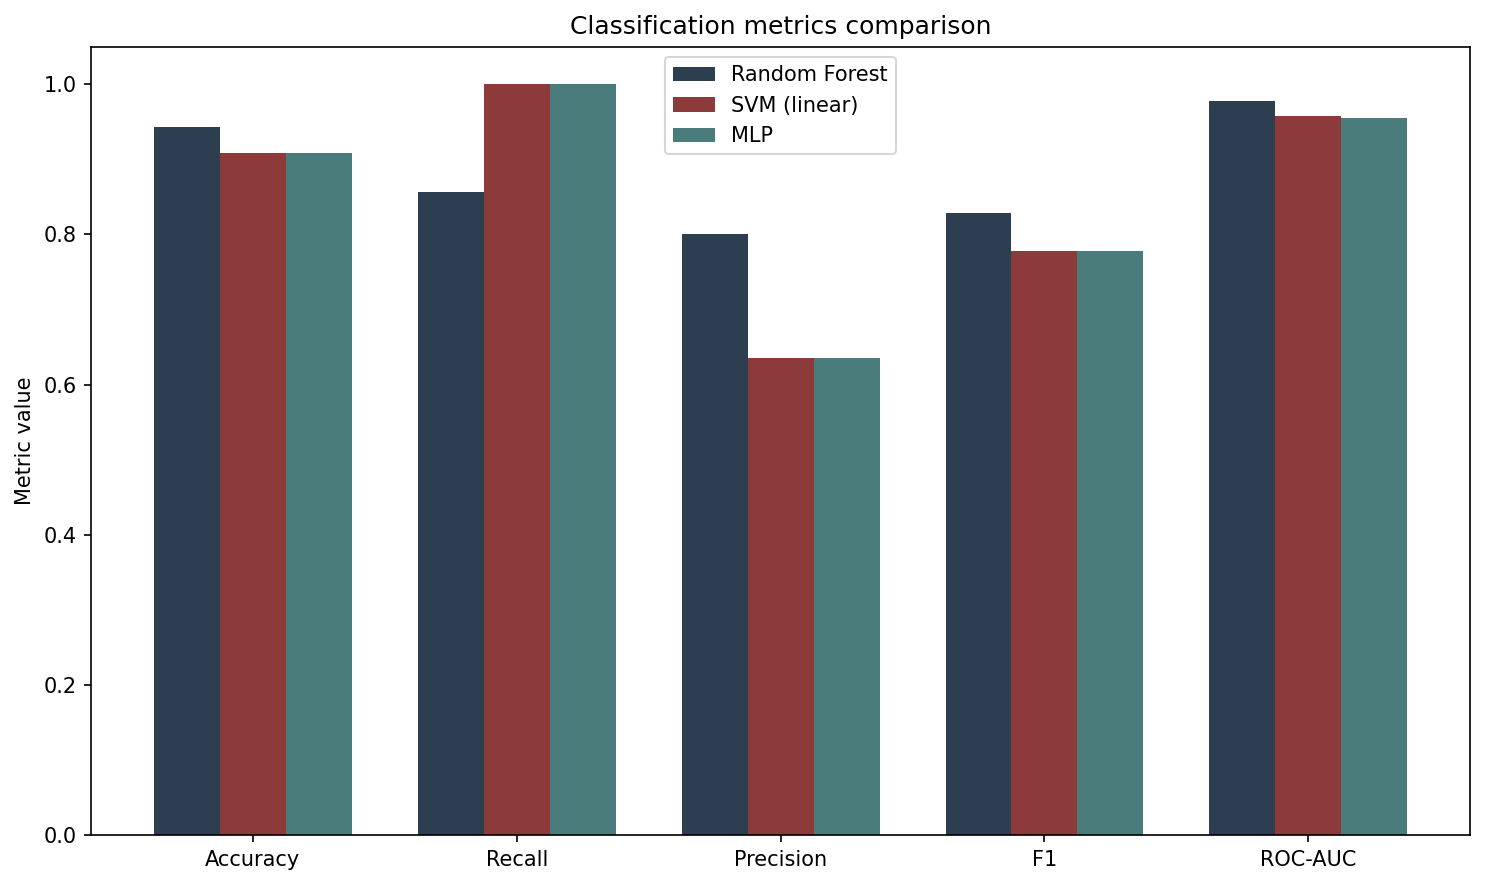

In [19]:
metrics_to_plot = ['Accuracy','Recall','Precision','F1','ROC-AUC']
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, name in enumerate(models):
    vals = [table51.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + (i-1)*width, vals, width, label=name, color=model_colors[name])
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Metric value'); ax.set_ylim(0,1.05)
ax.set_title('Classification metrics comparison')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_7_performance_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 16. Feature importance across all three classifiers

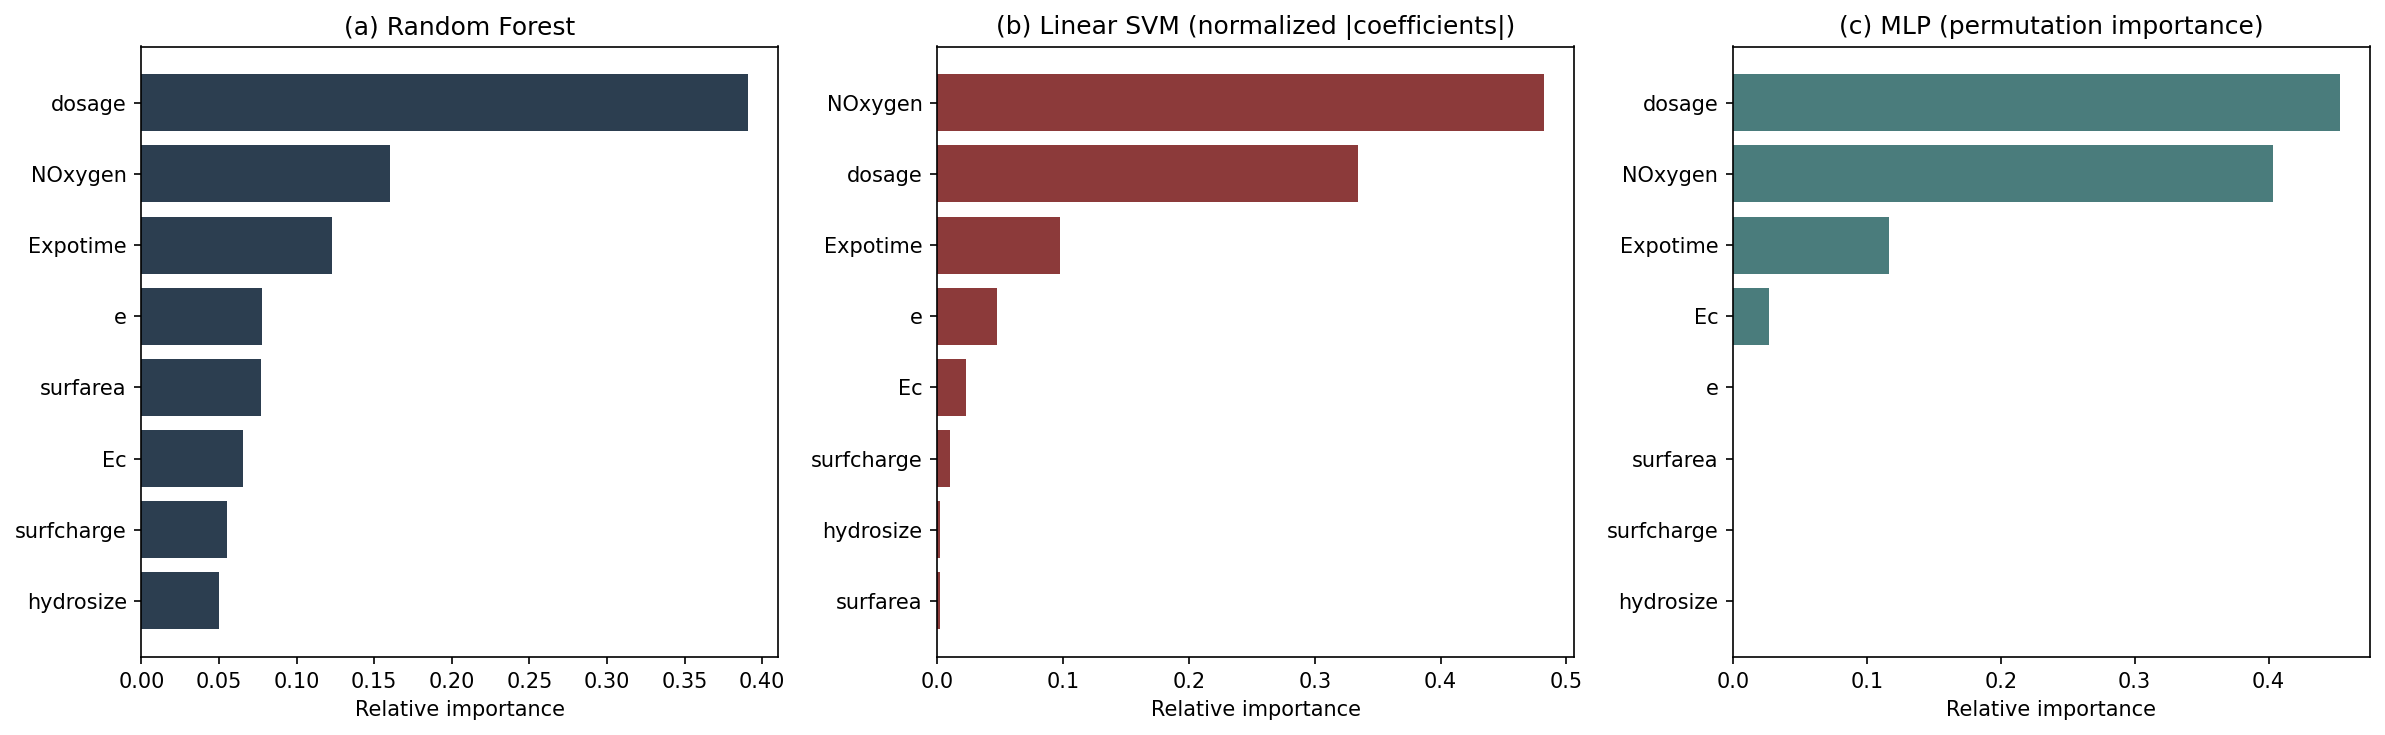

In [20]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(16,5))

rf_imp = models['Random Forest'].feature_importances_
order_rf = np.argsort(rf_imp)
axes[0].barh(np.array(features)[order_rf], rf_imp[order_rf], color=model_colors['Random Forest'])
axes[0].set_title('(a) Random Forest')

svm_imp = np.abs(models['SVM (linear)'].coef_[0])
svm_imp = svm_imp / svm_imp.sum()
order_svm = np.argsort(svm_imp)
axes[1].barh(np.array(features)[order_svm], svm_imp[order_svm], color=model_colors['SVM (linear)'])
axes[1].set_title('(b) Linear SVM (normalized |coefficients|)')

perm = permutation_importance(models['MLP'], X_test, y_test, n_repeats=30, random_state=RANDOM_SEED, n_jobs=1)
mlp_imp = np.clip(perm.importances_mean, 0, None)
mlp_imp = mlp_imp / mlp_imp.sum() if mlp_imp.sum() > 0 else mlp_imp
order_mlp = np.argsort(mlp_imp)
axes[2].barh(np.array(features)[order_mlp], mlp_imp[order_mlp], color=model_colors['MLP'])
axes[2].set_title('(c) MLP (permutation importance)')

for ax in axes: ax.set_xlabel('Relative importance')
plt.tight_layout()
plt.savefig('fig5_9_feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 17. Predicted probability distributions by true class

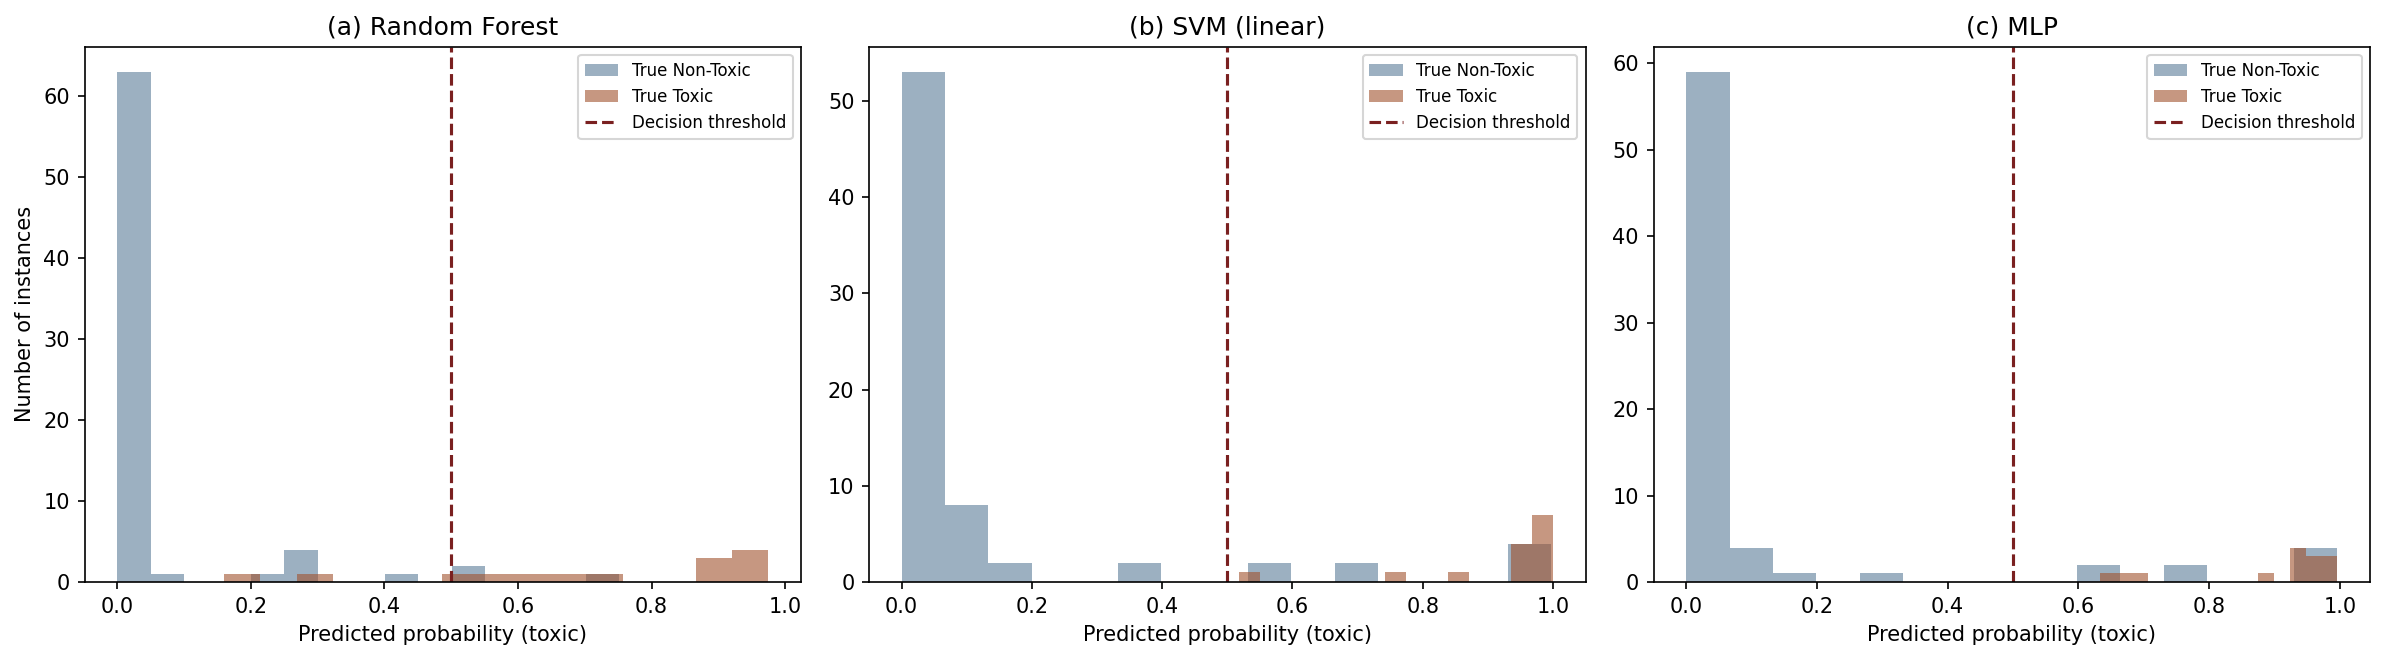

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for idx, name in enumerate(models):
    probs = y_probs[name]
    axes[idx].hist(probs[y_test==0], bins=15, alpha=0.6, label='True Non-Toxic', color=colors[3])
    axes[idx].hist(probs[y_test==1], bins=15, alpha=0.6, label='True Toxic', color=colors[5])
    axes[idx].axvline(0.5, color='#7a2020', linestyle='--', linewidth=1.5, label='Decision threshold')
    axes[idx].set_title(f'({chr(97+idx)}) {name}')
    axes[idx].set_xlabel('Predicted probability (toxic)')
    if idx==0: axes[idx].set_ylabel('Number of instances')
    axes[idx].legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig5_14_prediction_probability_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
